**DBSCAN**

Imports

In [14]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, MultiPoint
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


import contextily as ctx
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from math import radians, cos, sin, asin, sqrt

import json
from tqdm import tqdm
import folium
from folium import plugins, FeatureGroup, LayerControl
import random
import pygeohash as pgh
from itertools import combinations
from shapely.affinity import rotate, translate
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D
from shapely.ops import transform
from pyproj import CRS, Transformer

Coordinate system and parameters for DBSCAN

In [15]:
# Coordinate Reference System
CRS_WGS84 = "EPSG:4326"     
CRS_UTM   = "EPSG:32611"   

Load dataset

The following link needs to be updated in order to load the correct dataset of the AIS data. The link to download the dataset can be found in the README.md file of the preface directory.


In [16]:
csv_path = r"C:\\Users\\Korina\\Desktop\\AI\\project_final\\final-clean\\ProjectData_AIS_LA_2025.csv" 


df = pd.read_csv(csv_path)
df.head()


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,366988970,2024-08-12T00:00:04,33.76708,-118.22046,0.0,271.9,121.0,LARCONA,NaN,WDC2171,31.0,0.0,21.0,7.0,3.2,31.0,A
1,367401030,2024-08-12T00:00:04,33.75408,-118.26853,0.1,16.3,88.0,DELTA BILLIE,IMO9562207,WDE8059,31.0,0.0,30.0,12.0,5.5,31.0,A
2,367452280,2024-08-12T00:00:04,33.73528,-118.26908,0.0,360.0,511.0,LAGUNA,NaN,WDL6144,52.0,0.0,60.0,19.0,2.5,52.0,A
3,367580930,2024-08-12T00:00:00,33.73759,-118.16589,23.3,116.1,511.0,TRIUMPHANT,IMO9759692,WDG8773,60.0,0.0,26.0,10.0,0.0,60.0,A
4,367691660,2024-08-12T00:00:07,33.74880,-118.11409,0.0,270.0,511.0,BIBI,NaN,WDI3764,37.0,7.0,19.0,5.0,0.0,30.0,A


**Step 1**


Preprocess data (space, time, type, speed, heading, hourly)

In [17]:
time_col = "BaseDateTime"

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=[time_col])

lat_min, lat_max = 33.60, 33.85
lon_min, lon_max = -118.45, -118.15
start = pd.Timestamp("2024-08-01 00:00:00")
end = pd.Timestamp("2024-08-31 00:00:00")

df["SOG"] = pd.to_numeric(df["SOG"], errors="coerce")

mask = (
    df["LAT"].between(lat_min, lat_max)
    & df["LON"].between(lon_min, lon_max)
    & df[time_col].ge(start)
    & df[time_col].lt(end)
    & (df["VesselType"].between(70, 79) | df["VesselType"].between(80, 89))
    & df["SOG"].lt(1)
)

df_f = df.loc[mask].copy()

df_f["Length"] = pd.to_numeric(df_f["Length"], errors="coerce")
df_f["Width"] = pd.to_numeric(df_f["Width"], errors="coerce")
df_f["Heading"] = pd.to_numeric(df_f["Heading"], errors="coerce")

df_f = df_f.loc[
    df_f["Length"].gt(0)
    & df_f["Width"].gt(0)
    & df_f["Heading"].notna()
    & df_f["Heading"].ne(511)
].copy()

df_f = df_f.sort_values(["MMSI", time_col])

d_heading = df_f.groupby("MMSI")["Heading"].diff().abs()
d_heading = d_heading.where(d_heading.isna(), np.minimum(d_heading, 360 - d_heading))
df_f = df_f.loc[d_heading.isna() | d_heading.le(10)].copy()

df_hour = (
    df_f.drop_duplicates(subset=["MMSI", time_col], keep="last")
    .set_index(time_col)
    .groupby("MMSI")
    .resample("1h")
    .last()
)

df_hour = df_hour.drop(columns=["MMSI"], errors="ignore").reset_index()

df_hour["LAT_original"] = df_hour["LAT"]
df_hour["LON_original"] = df_hour["LON"]

lat_mean = df_hour["LAT"].mean()
lat_std = df_hour["LAT"].std()
lon_mean = df_hour["LON"].mean()
lon_std = df_hour["LON"].std()

df_hour["LAT"] = (df_hour["LAT"] - lat_mean) / lat_std
df_hour["LON"] = (df_hour["LON"] - lon_mean) / lon_std

standardization_params = {
    "lat_mean": lat_mean,
    "lat_std": lat_std,
    "lon_mean": lon_mean,
    "lon_std": lon_std,
}

------------------------------

**Step 2**


 Convert to GeoDataFrame  

In [18]:
cols_keep = ["MMSI", time_col, "LAT", "LON", "LAT_original", "LON_original",
             "SOG", "Heading", "VesselType", "Length", "Width"]  

df_clean = df_hour[cols_keep].dropna(subset=["LAT", "LON"]).copy()

print("DataFrame shape:", df_clean.shape)
print(f"  Original LAT range: [{df_clean['LAT_original'].min():.4f}, {df_clean['LAT_original'].max():.4f}]")
print(f"  Original LON range: [{df_clean['LON_original'].min():.4f}, {df_clean['LON_original'].max():.4f}]")
print(f"  Length range: [{df_clean['Length'].min():.1f}, {df_clean['Length'].max():.1f}]")
print(f"  Width range: [{df_clean['Width'].min():.1f}, {df_clean['Width'].max():.1f}]")


DataFrame shape: (26792, 11)
  Original LAT range: [33.6975, 33.7759]
  Original LON range: [-118.2817, -118.1500]
  Length range: [45.0, 400.0]
  Width range: [15.0, 60.0]


-------------------------

**Step 3**


Export csv only for cargo and tankers ( that we will use for DBSCAN)

In [19]:
output_filename = "preprocessed_la_port_cargo_tanker.csv"

df_clean.to_csv(output_filename, index=False)
print(f"Columns saved: {list(df_clean.columns)}")
print(f"Records saved: {len(df_clean):,}")
print(f"Unique vessels: {df_clean['MMSI'].nunique()}")
print(f"Date range: {(df_clean[time_col].max() - df_clean[time_col].min()).days} days")

Columns saved: ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'LAT_original', 'LON_original', 'SOG', 'Heading', 'VesselType', 'Length', 'Width']
Records saved: 26,792
Unique vessels: 363
Date range: 29 days


--------------------------

**Step 4**


Visualize points over Port of LA map

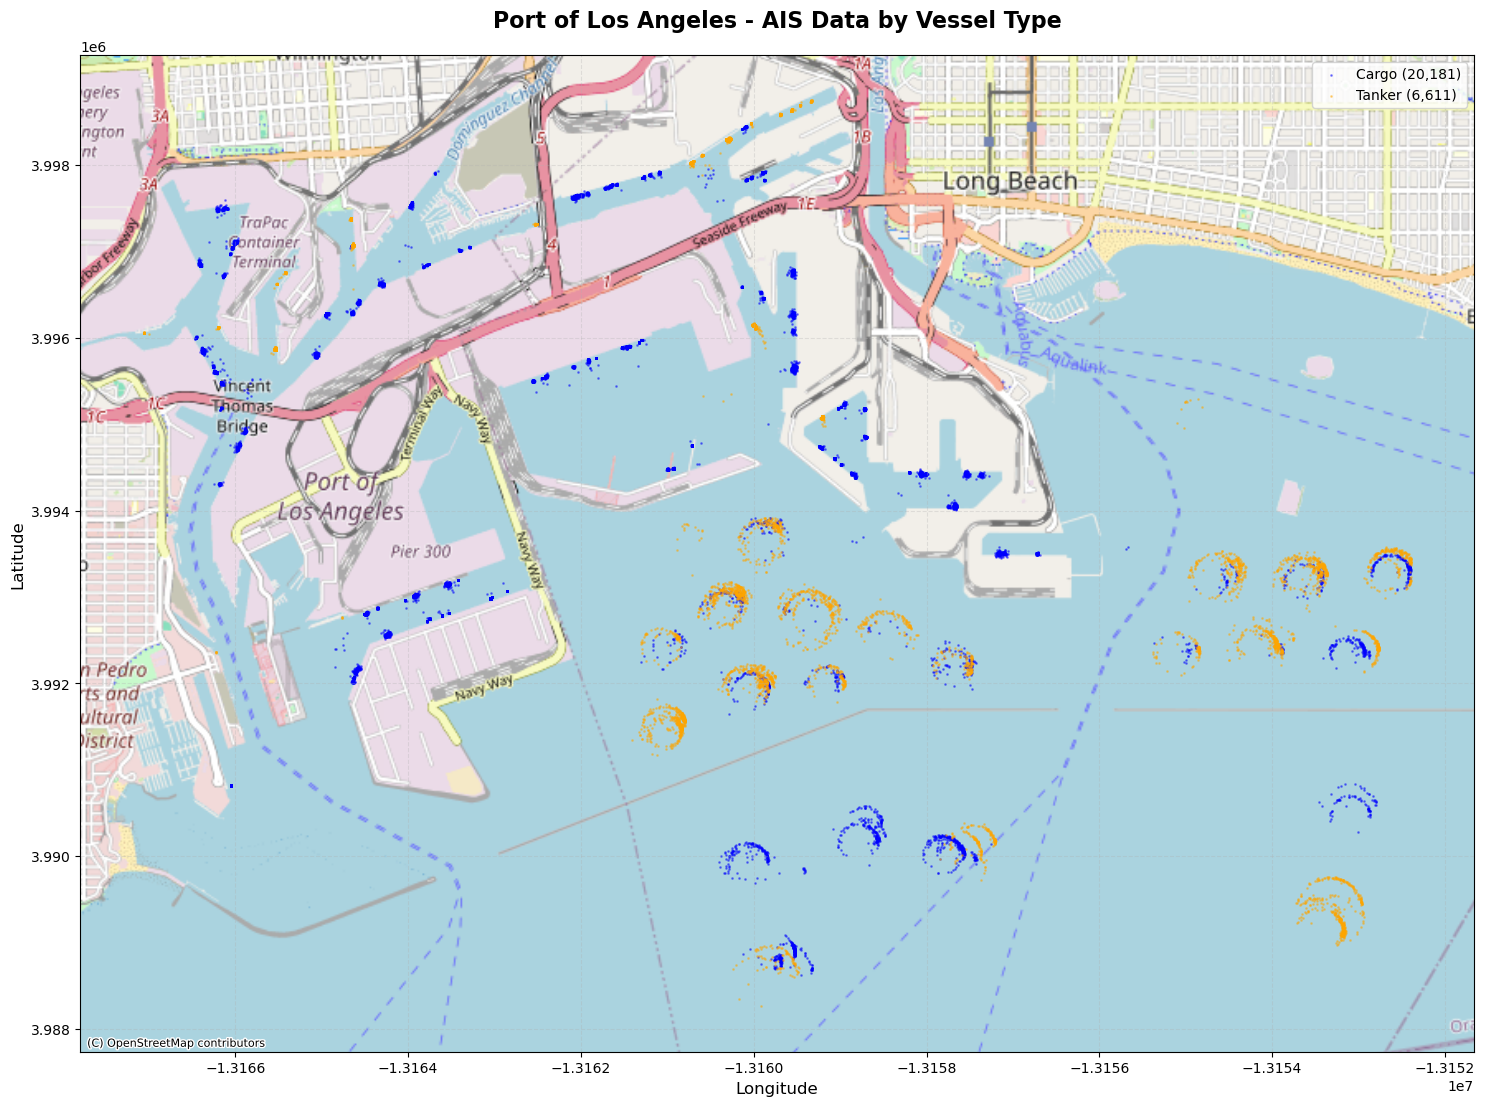

In [20]:
gdf_viz = gpd.GeoDataFrame(
    df_clean,
    geometry=gpd.points_from_xy(df_clean["LON_original"], df_clean["LAT_original"]),
    crs="EPSG:4326"
)

gdf_viz_projected = gdf_viz.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 12))

cargo = gdf_viz_projected[gdf_viz_projected["VesselType"].between(70, 79)]
tanker = gdf_viz_projected[gdf_viz_projected["VesselType"].between(80, 89)]

cargo.plot(ax=ax, markersize=1, alpha=0.4, color="blue", label=f"Cargo ({len(cargo):,})")
tanker.plot(ax=ax, markersize=1, alpha=0.4, color="orange", label=f"Tanker ({len(tanker):,})")

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=13,
    attribution_size=8
)

ax.set_title("Port of Los Angeles - AIS Data by Vessel Type",
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.savefig("port_la_ais_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

-------------------------------

**Step 5**

Split the dataset into <mark>2 datasets 

In [21]:
df_preprocessed = pd.read_csv("preprocessed_la_port_cargo_tanker.csv")

df_preprocessed["BaseDateTime"] = pd.to_datetime(
    df_preprocessed["BaseDateTime"], errors="coerce"
)

df_preprocessed["LAT"] = pd.to_numeric(df_preprocessed["LAT"], errors="coerce")
df_preprocessed["LON"] = pd.to_numeric(df_preprocessed["LON"], errors="coerce")
df_preprocessed = df_preprocessed.dropna(subset=["LAT", "LON"])

print(f"Loaded: {len(df_preprocessed):,} records")
print(f"Unique vessels: {df_preprocessed['MMSI'].nunique()}")
print("\n" + "=" * 70)
print("SPLITTING DATA INTO 2 DATASETS")
print("=" * 70)

vessel_counts = (
    df_preprocessed
    .groupby("MMSI")
    .size()
    .sort_values(ascending=False)
)

print(f"Total vessels: {len(vessel_counts)}")

split_assignment = {
    mmsi: idx % 2
    for idx, mmsi in enumerate(vessel_counts.index)
}

df_preprocessed["split"] = df_preprocessed["MMSI"].map(split_assignment)

split_0 = df_preprocessed[df_preprocessed["split"] == 0].copy()
split_1 = df_preprocessed[df_preprocessed["split"] == 1].copy()

print("\nSplit 0:")
print(f"  Records: {len(split_0):,}")
print(f"  Vessels: {split_0['MMSI'].nunique()}")

print("\nSplit 1:")
print(f"  Records: {len(split_1):,}")
print(f"  Vessels: {split_1['MMSI'].nunique()}")

splits = [split_0, split_1]


Loaded: 26,792 records
Unique vessels: 363

SPLITTING DATA INTO 2 DATASETS
Total vessels: 363

Split 0:
  Records: 13,617
  Vessels: 182

Split 1:
  Records: 13,175
  Vessels: 181


----------------------

**Step 6**


DBScan

In [22]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))
    r = 6371000  
    return c * r


EPS_METERS = 50  
MIN_SAMPLES = 3  
MIN_POINTS_PER_CLUSTER = 5
MIN_CLUSTER_AREA_M2 = 100
MAX_CLUSTER_AREA_M2 = 200_000


POINT_SIZE = 1
CLUSTER_EDGE_COLOR = "red"


def apply_dbscan_per_vessel(df, eps_meters, min_samples):
    filtered_data = []

    for mmsi, group in df.groupby("MMSI"):
        if len(group) < min_samples:
            continue

        coords_original = group[["LAT_original", "LON_original"]].values
        n = len(coords_original)
        dist_matrix = np.zeros((n, n), dtype=np.float32)

        for i in range(n):
            for j in range(i + 1, n):
                d = haversine_distance(
                    coords_original[i, 0], coords_original[i, 1],
                    coords_original[j, 0], coords_original[j, 1],
                )
                dist_matrix[i, j] = d
                dist_matrix[j, i] = d

        clustering = DBSCAN(
            eps=eps_meters,
            min_samples=min_samples,
            metric="precomputed",
        ).fit(dist_matrix)

        mask = clustering.labels_ != -1
        if mask.sum() > 0:
            filtered_data.append(group.loc[mask].copy())

    return (
        pd.concat(filtered_data, ignore_index=True)
        if filtered_data
        else pd.DataFrame(columns=df.columns)
    )

print("Using hyperparameters:")
print(f"  eps = {EPS_METERS} meters")
print(f"  min_samples = {MIN_SAMPLES} points (each point is 1 hour - total 3 hours)")

print("\nApplying DBSCAN to Split 0...")
split_0_filtered = apply_dbscan_per_vessel(split_0, EPS_METERS, MIN_SAMPLES)
print(
    f"  Before: {len(split_0):,} | After: {len(split_0_filtered):,} "
    f"({100 * len(split_0_filtered) / len(split_0):.1f}%)"
)

print("\nApplying DBSCAN to Split 1...")
split_1_filtered = apply_dbscan_per_vessel(split_1, EPS_METERS, MIN_SAMPLES)
print(
    f"  Before: {len(split_1):,} | After: {len(split_1_filtered):,} "
    f"({100 * len(split_1_filtered) / len(split_1):.1f}%)"
)

splits_filtered = [split_0_filtered, split_1_filtered]


Using hyperparameters:
  eps = 50 meters
  min_samples = 3 points (each point is 1 hour - total 3 hours)

Applying DBSCAN to Split 0...
  Before: 13,617 | After: 13,281 (97.5%)

Applying DBSCAN to Split 1...
  Before: 13,175 | After: 12,838 (97.4%)


-----------------------

**Step 7**

Add Vessel Dimensions

The following link needs to be updated in order to load the correct dataset of the AIS data. The link to download the dataset can be found in the README.md file of the preface directory.

In [23]:
# Load raw data to get dimensions
raw_data = pd.read_csv(r"C:\Users\Korina\Desktop\AI\project_final\final-clean\ProjectData_AIS_LA_2025.csv")


In [24]:
# Get unique vessel dimensions
vessel_dims = raw_data[['MMSI', 'Length', 'Width']].drop_duplicates(subset=['MMSI'])

print(f"Found dimensions for {len(vessel_dims)} unique vessels")

# FIX: Ensure MMSI types match
vessel_dims['MMSI'] = vessel_dims['MMSI'].astype(int)
split_0_filtered['MMSI'] = split_0_filtered['MMSI'].astype(int)
split_1_filtered['MMSI'] = split_1_filtered['MMSI'].astype(int)

# Convert Length/Width to DimensionA/B/C/D
vessel_dims['DimensionA'] = vessel_dims['Length'] / 2
vessel_dims['DimensionB'] = vessel_dims['Length'] / 2
vessel_dims['DimensionC'] = vessel_dims['Width'] / 2
vessel_dims['DimensionD'] = vessel_dims['Width'] / 2

print("\nSample vessel_dims:")
print(vessel_dims.head())

# CHECK: See if MMSIs overlap
split_0_mmsi = set(split_0_filtered['MMSI'].unique())
vessel_dims_mmsi = set(vessel_dims['MMSI'].unique())
overlap = split_0_mmsi & vessel_dims_mmsi


split_0_filtered = split_0_filtered.merge(
    vessel_dims[['MMSI', 'DimensionA', 'DimensionB', 'DimensionC', 'DimensionD']],
    on='MMSI',
    how='left'
)

split_1_filtered = split_1_filtered.merge(
    vessel_dims[['MMSI', 'DimensionA', 'DimensionB', 'DimensionC', 'DimensionD']],
    on='MMSI',
    how='left'
)

# Drop records with missing dimensions
before_0 = len(split_0_filtered)
split_0_filtered = split_0_filtered.dropna(subset=['DimensionA'])
after_0 = len(split_0_filtered)


split_1_filtered = split_1_filtered.dropna(subset=['DimensionA'])

print(f"Split 0: {len(split_0_filtered):,} points with dimensions")
print(f"Split 1: {len(split_1_filtered):,} points with dimensions")




Found dimensions for 1357 unique vessels

Sample vessel_dims:
        MMSI  Length  Width  DimensionA  DimensionB  DimensionC  DimensionD
0  366988970    21.0    7.0        10.5        10.5         3.5         3.5
1  367401030    30.0   12.0        15.0        15.0         6.0         6.0
2  367452280    60.0   19.0        30.0        30.0         9.5         9.5
3  367580930    26.0   10.0        13.0        13.0         5.0         5.0
4  367691660    19.0    5.0         9.5         9.5         2.5         2.5
Split 0: 13,281 points with dimensions
Split 1: 12,838 points with dimensions


-----------------

**Step 8**


Spatial Augmentation

In [25]:
import json

# Load standardization parameters
std_params = {
    "lat_mean": 33.74509766364515,
    "lat_std": 0.016767394905230753,
    "lon_mean": -118.22804109294896,
    "lon_std": 0.031475946327558416
}

def generate_augmented_points(df, n_points=10):
  
    augmented_records = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Augmenting", unit="msg"):
        # Original point coordinates (standardized)
        lat_std = row['LAT']
        lon_std = row['LON']

        # Original coordinates (for distance calculations)
        lat_orig = row['LAT_original']
        lon_orig = row['LON_original']

        # Vessel dimensions (in meters)
        dim_a = row['DimensionA']  # Distance to bow
        dim_b = row['DimensionB']  # Distance to stern
        dim_c = row['DimensionC']  # Distance to port
        dim_d = row['DimensionD']  # Distance to starboard

        # HEADING: Direction vessel is pointing (0° = North, 90° = East, etc.)
        heading = row['Heading']
        heading_rad = np.radians(heading)

        # Generate random points within vessel rectangle
        for _ in range(n_points):
            #  STEP 1: Generate random offsets in VESSEL'S LOCAL FRAME
            x_local = np.random.uniform(-dim_b, dim_a)  # Along length (stern to bow)
            y_local = np.random.uniform(-dim_c, dim_d)  # Along width (port to starboard)

            #  STEP 2: ROTATE by heading to align with vessel's orientation
            x_global = x_local * np.sin(heading_rad) + y_local * np.cos(heading_rad)
            y_global = x_local * np.cos(heading_rad) - y_local * np.sin(heading_rad)

            # STEP 3: Convert meter offsets to degree offsets
            meters_per_degree_lat = 111000
            meters_per_degree_lon = 111000 * np.cos(np.radians(lat_orig))

            lat_offset_deg = y_global / meters_per_degree_lat
            lon_offset_deg = x_global / meters_per_degree_lon

            #  STEP 4: Calculate new position in original coordinates
            new_lat_orig = lat_orig + lat_offset_deg
            new_lon_orig = lon_orig + lon_offset_deg

            #  STEP 5: Standardize the new coordinates
            new_lat_std = (new_lat_orig - std_params['lat_mean']) / std_params['lat_std']
            new_lon_std = (new_lon_orig - std_params['lon_mean']) / std_params['lon_std']

            #  STEP 6: Create augmented record
            aug_record = row.copy()
            aug_record['LAT'] = new_lat_std
            aug_record['LON'] = new_lon_std
            aug_record['LAT_original'] = new_lat_orig
            aug_record['LON_original'] = new_lon_orig
            aug_record['is_augmented'] = True

            augmented_records.append(aug_record)

        # Also keep the original point
        orig_record = row.copy()
        orig_record['is_augmented'] = False
        augmented_records.append(orig_record)

    return pd.DataFrame(augmented_records)


# ============================================================================
# APPLY SPATIAL AUGMENTATION TO ALL 4 SPLITS
# ============================================================================

N_POINTS_TRAINING = 10

print(f"\nGenerating {N_POINTS_TRAINING} augmented points per AIS message.")
print(f" Points are aligned with vessel heading direction")


print("Processing Split 0.")
split_0_augmented = generate_augmented_points(split_0_filtered, n_points=N_POINTS_TRAINING)
print(f"  Before: {len(split_0_filtered):,} → After: {len(split_0_augmented):,} points")

print("\nProcessing Split 1.")
split_1_augmented = generate_augmented_points(split_1_filtered, n_points=N_POINTS_TRAINING)
print(f"  Before: {len(split_1_filtered):,} → After: {len(split_1_augmented):,} points")


# Store augmented splits
splits_augmented = [split_0_augmented, split_1_augmented]

print("\n" + "="*70)
print(" SPATIAL AUGMENTATION COMPLETE")
print("="*70)
print("\nAugmented splits:")
for i, split in enumerate(splits_augmented):
    original_points = (~split['is_augmented']).sum()
    augmented_points = split['is_augmented'].sum()
    print(f"  Split {i}: {len(split):,} total ({original_points:,} original + {augmented_points:,} generated)")





Generating 10 augmented points per AIS message.
 Points are aligned with vessel heading direction
Processing Split 0.


Augmenting: 100%|██████████| 13281/13281 [00:39<00:00, 337.45msg/s]


  Before: 13,281 → After: 146,091 points

Processing Split 1.


Augmenting: 100%|██████████| 12838/12838 [00:37<00:00, 340.80msg/s]


  Before: 12,838 → After: 141,218 points

 SPATIAL AUGMENTATION COMPLETE

Augmented splits:
  Split 0: 146,091 total (13,281 original + 132,810 generated)
  Split 1: 141,218 total (12,838 original + 128,380 generated)


-----------------

**Step 8 additional**

Visualize augmented points in html

In [26]:
validation_data = split_0_augmented.copy()


original_data = validation_data[validation_data['is_augmented'] == False]
augmented_data = validation_data[validation_data['is_augmented'] == True]

print(f"Original AIS points: {len(original_data):,}")
print(f"Augmented points: {len(augmented_data):,}")


n_vessels_to_show = min(500, len(original_data))
original_sample = original_data.sample(n=n_vessels_to_show, random_state=42)

mmsi_to_show = original_sample['MMSI'].unique()
augmented_sample = augmented_data[augmented_data['MMSI'].isin(mmsi_to_show)]
center_lat = original_sample['LAT_original'].mean()
center_lon = original_sample['LON_original'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=15,
    tiles='OpenStreetMap',
    control_scale=True
)


folium.TileLayer('CartoDB positron', name='Light Map').add_to(m)
folium.TileLayer('CartoDB dark_matter', name='Dark Map').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Satellite',
    overlay=False,
    control=True
).add_to(m)


original_group = folium.FeatureGroup(name='Original AIS Messages', show=True)

for idx, row in tqdm(original_sample.iterrows(), total=len(original_sample), desc="Adding original", unit="pt"):
    mmsi = row['MMSI']
    heading = row['Heading']

    
    aug_count = len(augmented_data[
        (augmented_data['MMSI'] == mmsi) &
        (np.abs(augmented_data['LAT_original'] - row['LAT_original']) < 0.0001)
    ])

    folium.CircleMarker(
        location=[row['LAT_original'], row['LON_original']],
        radius=8,
        color='red',
        fill=True,
        fillColor='yellow',
        fillOpacity=1,
        weight=2,
        popup=folium.Popup(
            f"""
            <div style="font-family: Arial; width: 220px;">
                <h4 style="margin: 0; color: red;">Original AIS Message</h4>
                <hr style="margin: 5px 0;">
                <b>MMSI:</b> {mmsi}<br>
                <b>Heading:</b> {heading:.1f}°<br>
                <b>Dimensions:</b> {row['DimensionA']+row['DimensionB']:.0f}m × {row['DimensionC']+row['DimensionD']:.0f}m<br>
                <b>Augmented points:</b> {aug_count}<br>
                <hr style="margin: 5px 0;">
                <small>Yellow star = actual vessel position</small>
            </div>
            """,
            max_width=250
        ),
        tooltip=f"<b>MMSI {mmsi}</b><br>Heading: {heading:.1f}°<br>{aug_count} augmented pts"
    ).add_to(original_group)

original_group.add_to(m)



augmented_group = folium.FeatureGroup(name=' Augmented Points (10 per vessel)', show=True)


colors = ['blue', 'green', 'purple', 'orange', 'darkred', 'darkblue',
          'darkgreen', 'cadetblue', 'darkpurple', 'pink']

vessel_colors = {}
for i, mmsi in enumerate(mmsi_to_show):
    vessel_colors[mmsi] = colors[i % len(colors)]

for idx, row in tqdm(augmented_sample.iterrows(), total=len(augmented_sample), desc="Adding augmented", unit="pt"):
    mmsi = row['MMSI']
    color = vessel_colors.get(mmsi, 'blue')

    folium.CircleMarker(
        location=[row['LAT_original'], row['LON_original']],
        radius=3,
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.6,
        weight=0,
        popup=f"""
        <b>Augmented Point</b><br>
        MMSI: {mmsi}<br>
        Heading: {row['Heading']:.1f}°<br>
        Type: Generated from spatial augmentation
        """
    ).add_to(augmented_group)

augmented_group.add_to(m)



folium.LayerControl(position='topright', collapsed=False).add_to(m)

plugins.Fullscreen(
    position='topleft',
    title='Fullscreen',
    title_cancel='Exit fullscreen',
    force_separate_button=True
).add_to(m)

plugins.MeasureControl(
    position='topleft',
    primary_length_unit='meters',
    secondary_length_unit='kilometers'
).add_to(m)

plugins.MiniMap(toggle_display=True, position='bottomleft').add_to(m)

output_file = 'validation_augmentation.html'
m.save(output_file)


Original AIS points: 13,281
Augmented points: 132,810


Adding augmented: 100%|██████████| 124570/124570 [00:16<00:00, 7559.14pt/s]


------------------

<mark>Note: 


The above cell that creates the html is only for visual validation that the augmented points were generated correctly. 

In the following cell, the spatially augmented AIS points are visualized, with vessel heading indicated to illustrate the direction of ship orientation.

------------------

Selected 6 vessels with diverse headings

Vessel 1: MMSI=366734000, Heading=11.0°, North (0-45°)
Vessel 2: MMSI=636017229, Heading=59.0°, Northeast (45-90°)
Vessel 3: MMSI=477737600, Heading=90.0°, East (90-135°)
Vessel 4: MMSI=538005178, Heading=177.0°, Southeast (135-180°)
Vessel 5: MMSI=563161200, Heading=202.0°, South (180-225°)
Vessel 6: MMSI=256029000, Heading=244.0°, Southwest (225-270°)


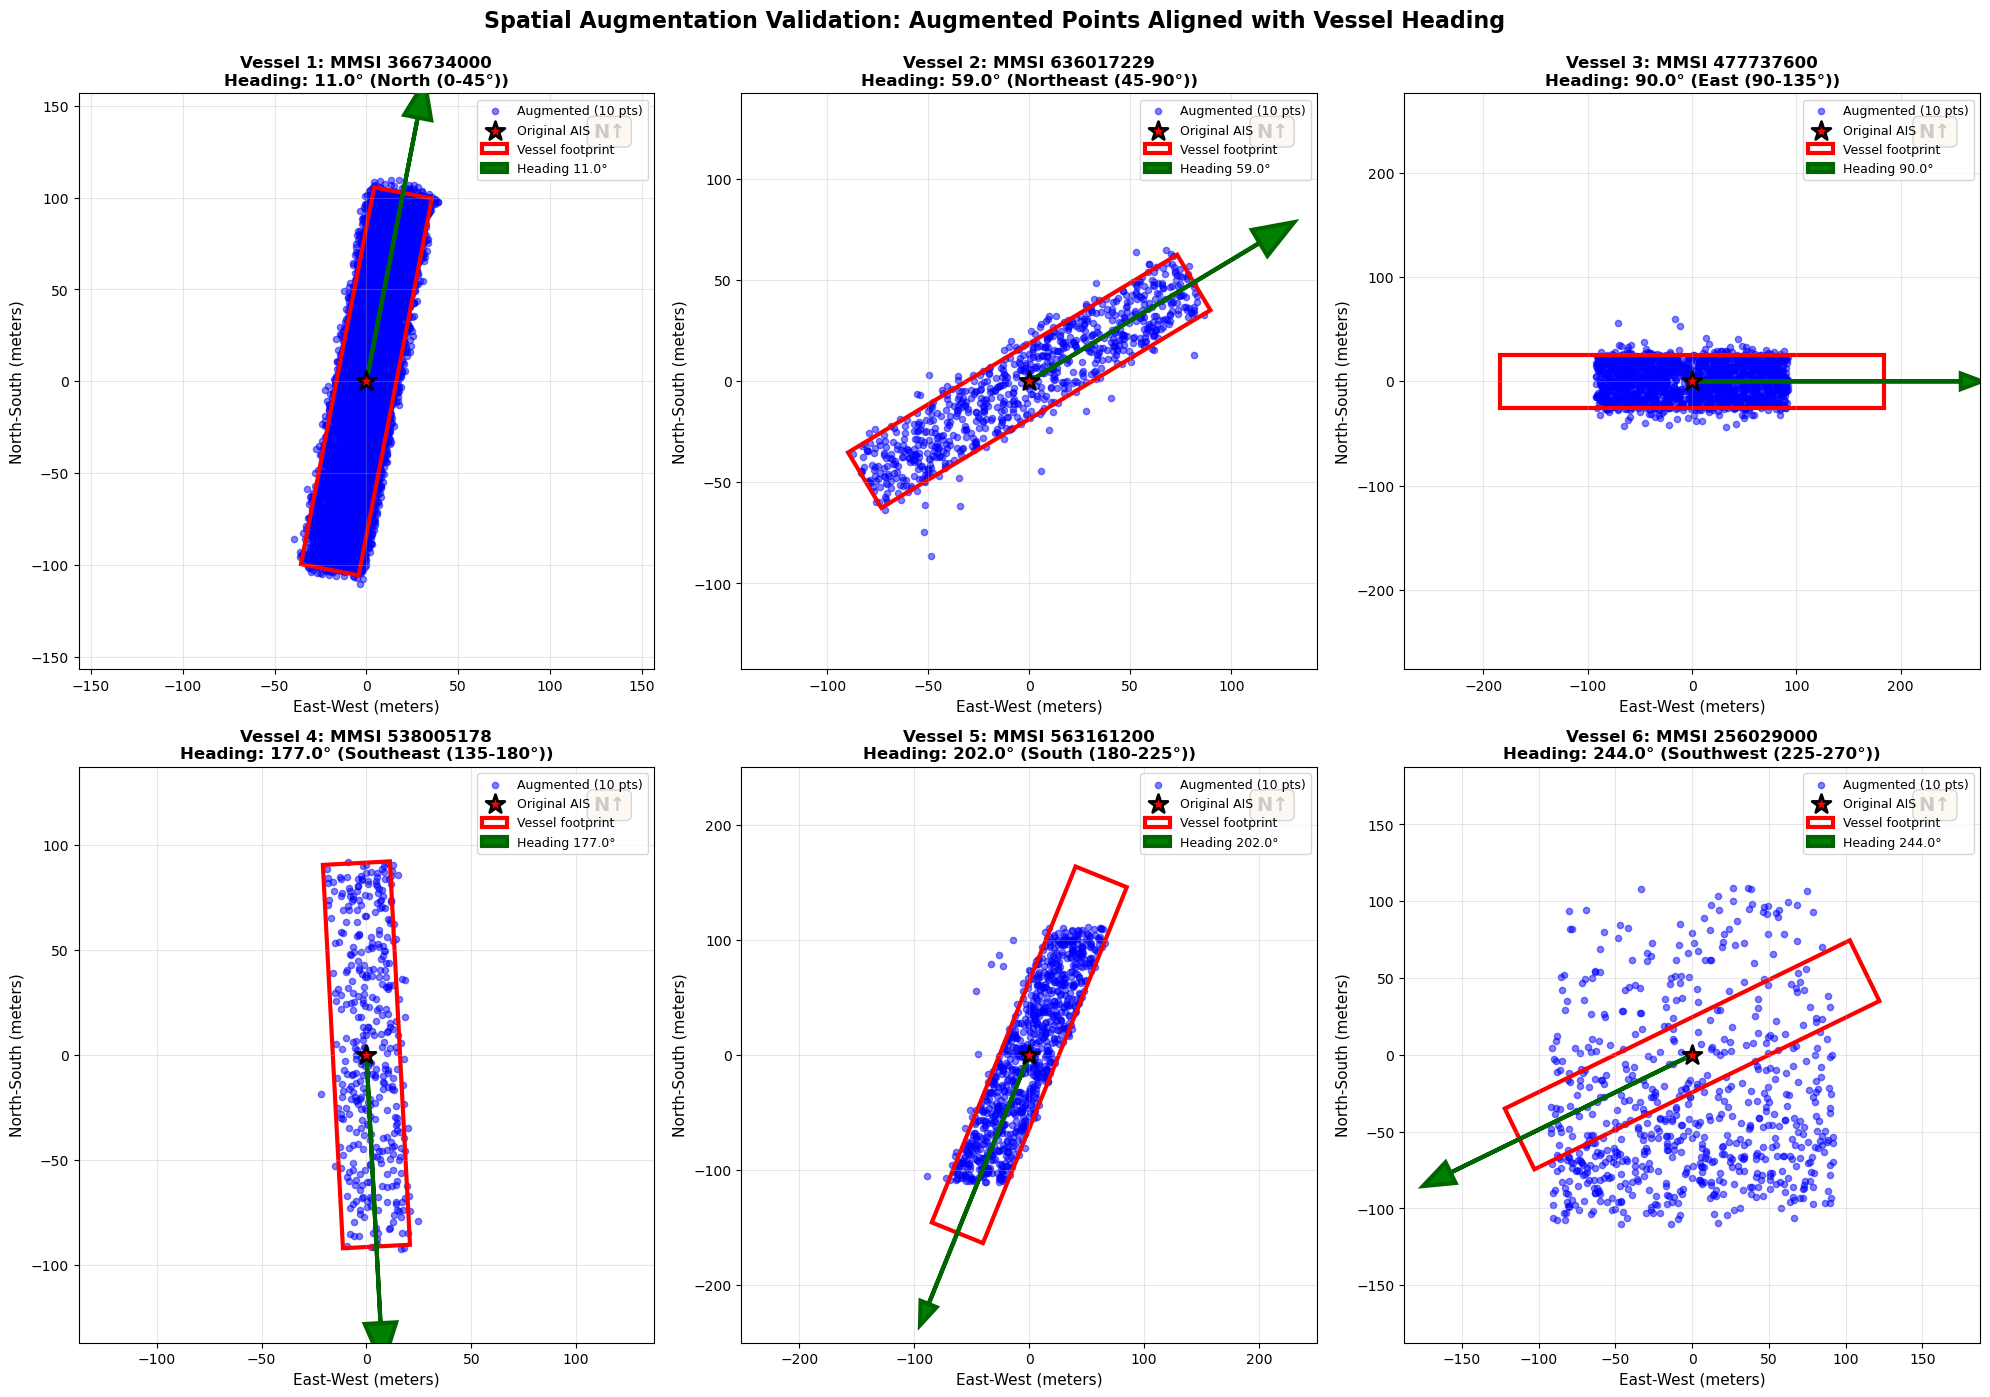


Split 0:
  Original points: 13,281
  Augmented points: 132,810

Split 1:
  Original points: 12,838
  Augmented points: 128,380


In [ ]:
original_points = split_0_augmented[split_0_augmented['is_augmented'] == False].copy()
vessels_to_plot = []
heading_ranges = [
    (0, 45, "North (0-45°)"),
    (45, 90, "Northeast (45-90°)"),
    (90, 135, "East (90-135°)"),
    (135, 180, "Southeast (135-180°)"),
    (180, 225, "South (180-225°)"),
    (225, 270, "Southwest (225-270°)"),
    (270, 315, "West (270-315°)"),
    (315, 360, "Northwest (315-360°)")
]

for h_min, h_max, label in heading_ranges:
    candidates = original_points[
        (original_points['Heading'] >= h_min) &
        (original_points['Heading'] < h_max)
    ]
    if len(candidates) > 0:
        vessel = candidates.sample(1).iloc[0]
        vessels_to_plot.append((vessel, label))
        if len(vessels_to_plot) >= 6:  
            break

print(f"Selected {len(vessels_to_plot)} vessels with diverse headings\n")

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

for idx, (vessel, heading_label) in enumerate(vessels_to_plot):
    if idx >= 6:
        break

    ax = axes[idx]

    mmsi = vessel['MMSI']
    heading = vessel['Heading']
    lat_orig = vessel['LAT_original']
    lon_orig = vessel['LON_original']

    
    dim_a = vessel['DimensionA']
    dim_b = vessel['DimensionB']
    dim_c = vessel['DimensionC']
    dim_d = vessel['DimensionD']

    print(f"Vessel {idx+1}: MMSI={mmsi}, Heading={heading:.1f}°, {heading_label}")

    vessel_data = split_0_augmented[
        (split_0_augmented['MMSI'] == mmsi) &
        (np.abs(split_0_augmented['LAT_original'] - lat_orig) < 0.001) &
        (np.abs(split_0_augmented['LON_original'] - lon_orig) < 0.001)
    ]

    
    original = vessel_data[vessel_data['is_augmented'] == False]
    augmented = vessel_data[vessel_data['is_augmented'] == True]

    def to_meters(lat_list, lon_list, lat_ref, lon_ref):
    
        lat_m = (lat_list - lat_ref) * 111000
        lon_m = (lon_list - lon_ref) * 111000 * np.cos(np.radians(lat_ref))
        return lon_m, lat_m  

   
    if len(augmented) > 0:
        aug_x, aug_y = to_meters(
            augmented['LAT_original'].values,
            augmented['LON_original'].values,
            lat_orig, lon_orig
        )
        ax.scatter(aug_x, aug_y, c='blue', s=20, alpha=0.5, label='Augmented (10 pts)')

    
    ax.scatter([0], [0], c='red', s=200, marker='*',
               edgecolors='black', linewidths=2,
               label='Original AIS', zorder=10)

    
    vessel_length = dim_a + dim_b
    vessel_width = dim_c + dim_d

    
    rect = Rectangle(
        (-dim_b, -dim_c),  
        vessel_length,      
        vessel_width,       
        linewidth=3,
        edgecolor='red',
        facecolor='none',
        label='Vessel footprint'
    )

    
    angle_mpl = 90 - heading  

    t = Affine2D().rotate_deg(angle_mpl) + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)

    arrow_length = max(vessel_length, vessel_width) * 0.7
    
    heading_rad = np.radians(heading)
    arrow_dx = arrow_length * np.sin(heading_rad)  
    arrow_dy = arrow_length * np.cos(heading_rad) 

    ax.arrow(0, 0, arrow_dx, arrow_dy,
             head_width=15, head_length=20,
             fc='green', ec='darkgreen',
             linewidth=3, zorder=5,
             label=f'Heading {heading:.1f}°')

   
    ax.set_xlabel('East-West (meters)', fontsize=11)
    ax.set_ylabel('North-South (meters)', fontsize=11)
    ax.set_title(f'Vessel {idx+1}: MMSI {mmsi}\nHeading: {heading:.1f}° ({heading_label})',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=9)

   
    max_range = max(vessel_length, vessel_width) * 1.5
    ax.set_xlim(-max_range/2, max_range/2)
    ax.set_ylim(-max_range/2, max_range/2)

    
    ax.text(0.95, 0.95, 'N↑', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

for idx in range(len(vessels_to_plot), 6):
    axes[idx].axis('off')

plt.suptitle('Spatial Augmentation Validation: Augmented Points Aligned with Vessel Heading',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('augmentation_validation_heading.png', dpi=300, bbox_inches='tight')
plt.show()


for i, split in enumerate([split_0_augmented, split_1_augmented]):
    original = split[split['is_augmented'] == False]
    augmented = split[split['is_augmented'] == True]

    print(f"\nSplit {i}:")
    print(f"  Original points: {len(original):,}")
    print(f"  Augmented points: {len(augmented):,}")
    

-------------

**Step 9**


Geohash Encoding

The points are encoded into geohashes of precision 9 (~4.7m x 4.7m grid cells). This reduces dataset size while preserving spatial structure, as multiple points within the same geohash are aggregated.

In [ ]:
def apply_geohash_encoding(df, precision=9):
    print(f"  Encoding with precision {precision} (~4.7m × 4.7m grid)")
    print(f"  Before: {len(df):,} points")

    
    df_copy = df.copy()

    geohashes = []
    for idx, row in tqdm(df_copy.iterrows(), total=len(df_copy), desc="  Generating geohashes", unit="pt"):
        geohash = pgh.encode(
            latitude=row['LAT_original'],
            longitude=row['LON_original'],
            precision=precision
        )
        geohashes.append(geohash)

    df_copy['geohash'] = geohashes

   
    print("  Aggregating by geohash...")
    df_encoded = df_copy.groupby('geohash', as_index=False).agg({
        'LAT': 'mean',          
        'LON': 'mean',
        'LAT_original': 'mean', 
        'LON_original': 'mean',
        'MMSI': 'first',        
        'Heading': 'mean',
        'DimensionA': 'first',
        'DimensionB': 'first',
        'DimensionC': 'first',
        'DimensionD': 'first',
        'BaseDateTime': 'first',
        'VesselType': 'first',
        'is_augmented': 'first'
    })

    print(f"  After: {len(df_encoded):,} points")
    print(f"  Reduction: {100*(1 - len(df_encoded)/len(df)):.1f}%")

    return df_encoded



GEOHASH_PRECISION = 9  

splits_to_encode = [
    (split_0_augmented, "Split 0"),
    (split_1_augmented, "Split 1")]

splits_geohash = []

for split_data, split_name in tqdm(splits_to_encode, desc="Overall progress", unit="split"):
    print(f"\n{split_name}:")
    encoded = apply_geohash_encoding(split_data, precision=GEOHASH_PRECISION)
    splits_geohash.append(encoded)


split_0_geohash, split_1_geohash = splits_geohash


print("\nSize comparison:")
print(f"{'Split':<10} {'Before Geohash':<20} {'After Geohash':<20} {'Reduction':<15}")
print("-" * 70)

augmented_splits = [split_0_augmented, split_1_augmented]

for i in range(2):
    before = len(augmented_splits[i])
    after = len(splits_geohash[i])
    reduction = 100 * (1 - after/before)
    print(f"Split {i:<4} {before:>15,} {after:>19,} {reduction:>13.1f}%")

total_before = sum(len(s) for s in augmented_splits)
total_after = sum(len(s) for s in splits_geohash)
print("-" * 70)
print(f"{'TOTAL':<10} {total_before:>15,} {total_after:>19,} {100*(1-total_after/total_before):>13.1f}%")



Overall progress:   0%|          | 0/2 [00:00<?, ?split/s]


Split 0:
  Encoding with precision 9 (~4.7m × 4.7m grid)
  Before: 146,091 points


Overall progress:  50%|█████     | 1/2 [00:05<00:05,  5.56s/split]

  Aggregating by geohash...
  After: 61,192 points
  Reduction: 58.1%

Split 1:
  Encoding with precision 9 (~4.7m × 4.7m grid)
  Before: 141,218 points


Overall progress: 100%|██████████| 2/2 [00:10<00:00,  5.41s/split]

  Aggregating by geohash...
  After: 63,874 points
  Reduction: 54.8%

Size comparison:
Split      Before Geohash       After Geohash        Reduction      
----------------------------------------------------------------------
Split 0            146,091              61,192          58.1%
Split 1            141,218              63,874          54.8%
----------------------------------------------------------------------
TOTAL              287,309             125,066          56.5%


------------

**Step 10**

GMM TRAINING

In [29]:

import os
import numpy as np
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from sklearn.mixture import GaussianMixture
from tqdm import tqdm


PHYSICAL_CORES = 8
N_JOBS = min(PHYSICAL_CORES, os.cpu_count() or PHYSICAL_CORES)   
THREADS_PER_JOB = 1 


def calculate_mdl_from_score(score_mean_ll: float, N: int, NF: int, NC: int) -> float:
    """
    score_mean_ll = gmm.score(data)  (mean log-likelihood per sample)
    """
   
    NM = NC * (2 * NF + NF * (NF + 1) / 2 + 1) - 1

   
    log_likelihood = score_mean_ll * N

   
    return (0.5 * NM * np.log2(N)) - log_likelihood


def _fit_score_mdl(n_components: int, data: np.ndarray, seed: int = 42) -> tuple[int, float]:
    """
    Fits a GMM and returns (n_components, mdl).
    Returns mdl=+inf if fit fails.
    """
    try:
      
        with threadpool_limits(limits=THREADS_PER_JOB):
            gmm = GaussianMixture(
                n_components=n_components,
                covariance_type="full",
                n_init=2,
                tol=1e-4,
                random_state=seed,
                max_iter=100,
                reg_covar=1e-6,
            )
            gmm.fit(data)
            mdl = calculate_mdl_from_score(gmm.score(data), N=len(data), NF=data.shape[1], NC=n_components)
        return n_components, mdl
    except Exception:
        return n_components, float("inf")


def find_optimal_n_components_parallel(data: np.ndarray, n_range, split_name: str = "Split"):
    print(f"\n  Finding optimal n_components for {split_name}...")
    print(f"  Testing range: {n_range[0]} to {n_range[-1]} (jobs={N_JOBS}, threads/job={THREADS_PER_JOB})")


    results = Parallel(n_jobs=N_JOBS, prefer="threads", batch_size="auto")(
        delayed(_fit_score_mdl)(k, data, 42)
        for k in tqdm(list(n_range), desc=f"  MDL search ({split_name})", leave=False, unit="comp")
    )

 
    mdl_scores = [(k, mdl) for (k, mdl) in results if np.isfinite(mdl)]
    if not mdl_scores:
        raise RuntimeError(f"No successful GMM fits for {split_name} in range {n_range[0]}..{n_range[-1]}")

    best_n, best_mdl = min(mdl_scores, key=lambda x: x[1])
    print(f"   Optimal n_components: {best_n} (MDL: {best_mdl:.2f})")
    return best_n, mdl_scores


def _train_gmm_one_split(data: np.ndarray, n_components: int, split_name: str):
    print(f"\n{split_name}:")
    print(f"  Data points: {len(data):,}")
    print(f"  Training GMM with {n_components} components...")

    with threadpool_limits(limits=THREADS_PER_JOB):
        gmm = GaussianMixture(
            n_components=n_components,
            covariance_type="full",
            n_init=5,
            tol=1e-5,
            random_state=42,
            max_iter=200,
            reg_covar=1e-6,
        )
        gmm.fit(data)

    print(f"   GMM trained (converged: {gmm.converged_})")
    return gmm



n_components_range = range(5, 101)
print(f"\nSearch range: {n_components_range.start} to {n_components_range.stop - 1} components")
print("Processing 2 splits...\n")

split_names = ["Split 0", "Split 1"]

optimal_components = []
all_mdl_scores = {}

for split, split_name in zip(splits_geohash, split_names):
    coords = split[["LON", "LAT"]].to_numpy(dtype=np.float64, copy=False)

    optimal_n, mdl_scores = find_optimal_n_components_parallel(
        coords,
        n_components_range,
        split_name=split_name
    )

    optimal_components.append(optimal_n)
    all_mdl_scores[split_name] = mdl_scores

print("\n" + "-" * 70)
print("Optimal components per split:")
for i, n in enumerate(optimal_components):
    print(f"  Split {i}: {n} components")

avg_components = int(np.mean(optimal_components))
print(f"\nAverage: {avg_components} components")
print(f"Using: {avg_components} components for all splits (for consistency)")

print("\n" + "=" * 70)
print("STEP 2: TRAINING FINAL GMMs")
print("=" * 70)
print(f"\nTraining 2 GMMs with {avg_components} components each (jobs={min(2, N_JOBS)})...\n")

coords_list = [
    splits_geohash[i][["LON", "LAT"]].to_numpy(dtype=np.float64, copy=False)
    for i in range(2)
]

trained_gmms = Parallel(n_jobs=min(2, N_JOBS), prefer="threads")(
    delayed(_train_gmm_one_split)(coords_list[i], avg_components, f"Split {i}")
    for i in range(2)
)

gmm_0, gmm_1 = trained_gmms

print(f"\nTrained {len(trained_gmms)} GMMs:")
for i, gmm in enumerate(trained_gmms):
    print(f"  Split {i}: {gmm.n_components} components, converged={gmm.converged_}")

gmm_data = {
    "gmms": trained_gmms,
    "n_components": avg_components,
    "optimal_components_per_split": optimal_components,
    "mdl_scores": all_mdl_scores,
}


Search range: 5 to 100 components
Processing 2 splits...


  Finding optimal n_components for Split 0...
  Testing range: 5 to 100 (jobs=8, threads/job=1)


   Optimal n_components: 95 (MDL: -23593.67)

  Finding optimal n_components for Split 1...
  Testing range: 5 to 100 (jobs=8, threads/job=1)


   Optimal n_components: 98 (MDL: -19945.79)

----------------------------------------------------------------------
Optimal components per split:
  Split 0: 95 components
  Split 1: 98 components

Average: 96 components
Using: 96 components for all splits (for consistency)

STEP 2: TRAINING FINAL GMMs

Training 2 GMMs with 96 components each (jobs=2)...


Split 0:
  Data points: 61,192
  Training GMM with 96 components...

Split 1:
  Data points: 63,874
  Training GMM with 96 components...
   GMM trained (converged: True)
   GMM trained (converged: True)

Trained 2 GMMs:
  Split 0: 96 components, converged=True
  Split 1: 96 components, converged=True


------------

In [30]:
for i, s in enumerate(splits_geohash):
    lat_min, lat_max = s["LAT"].min(), s["LAT"].max()
    lon_min, lon_max = s["LON"].min(), s["LON"].max()
    print(f"Split {i}: LAT [{lat_min:.6f}, {lat_max:.6f}] | LON [{lon_min:.6f}, {lon_max:.6f}]")


Split 0: LAT [-2.699586, 1.816832] | LON [-1.562118, 2.517867]
Split 1: LAT [-2.685390, 1.863810] | LON [-1.736506, 2.511327]


In [31]:

OUT_HTML = "port_gmm_visualization.html"
POINTS_PER_SPLIT = 5000
ELLIPSE_PTS = 60
N_STD = 2.0
COLORS = ["red", "blue", "green", "purple"]


def subsample(df, n):
    if len(df) <= n:
        return df
    return df.sample(n=n, random_state=42)

def gaussian_ellipse_points(mean_lonlat, cov_lonlat, n_std=2.0, n=60):
    """Ellipse points for 2D Gaussian in (lon,lat)."""
    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    eigvals, eigvecs = np.linalg.eigh(cov_lonlat)
    eigvals = np.maximum(eigvals, 1e-12)
    A = eigvecs @ np.diag(np.sqrt(eigvals))

    pts = mean_lonlat.reshape(2, 1) + n_std * (A @ circle)
    return pts.T  # (n,2) [lon,lat]

def fit_affine(z, x):
    """
    Fit x ≈ a*z + b (least squares), returns (a,b).
    Works even if z isn't perfectly mean=0,std=1.
    """
    z = np.asarray(z, dtype=float)
    x = np.asarray(x, dtype=float)
    m = np.isfinite(z) & np.isfinite(x)
    z = z[m]; x = x[m]
    if len(z) < 10:
        raise RuntimeError("Not enough valid points to fit affine transform.")

    z_mean = z.mean()
    x_mean = x.mean()
    var_z = np.var(z)
    if var_z < 1e-12:
        raise RuntimeError("Standardized column has ~zero variance; cannot fit transform.")

    cov_zx = np.mean((z - z_mean) * (x - x_mean))
    a = cov_zx / var_z
    b = x_mean - a * z_mean
    return float(a), float(b)


assert "splits_geohash" in globals(), "splits_geohash not found"
assert "trained_gmms" in globals(), "trained_gmms not found"
assert len(splits_geohash) == 2 and len(trained_gmms) == 2, "Need 2 splits and 2 trained GMMs"

needed = ["LAT", "LON", "LAT_original", "LON_original"]
for i, s in enumerate(splits_geohash):
    missing = [c for c in needed if c not in s.columns]
    if missing:
        raise RuntimeError(f"Split {i} missing columns: {missing}")


all_df = None
try:
    import pandas as pd
    all_df = pd.concat(splits_geohash, ignore_index=True)
except Exception:
    pass

if all_df is not None:
    z_lon = all_df["LON"].values
    x_lon = all_df["LON_original"].values
    z_lat = all_df["LAT"].values
    x_lat = all_df["LAT_original"].values
else:
    z_lon = np.concatenate([s["LON"].values for s in splits_geohash])
    x_lon = np.concatenate([s["LON_original"].values for s in splits_geohash])
    z_lat = np.concatenate([s["LAT"].values for s in splits_geohash])
    x_lat = np.concatenate([s["LAT_original"].values for s in splits_geohash])

a_lon, b_lon = fit_affine(z_lon, x_lon)
a_lat, b_lat = fit_affine(z_lat, x_lat)


D = np.diag([a_lon, a_lat])

print("Estimated inverse transform:")
print(f"  LON_original ≈ {a_lon:.6f} * LON + {b_lon:.6f}")
print(f"  LAT_original ≈ {a_lat:.6f} * LAT + {b_lat:.6f}")

def z_to_lonlat_params(mean_z, cov_z):
    """
    mean_z: [LON_z, LAT_z]
    cov_z: 2x2 covariance in z-space
    returns mean_x, cov_x in original lon/lat degrees
    """
    mean_x = np.array([a_lon * mean_z[0] + b_lon, a_lat * mean_z[1] + b_lat], dtype=float)
    cov_x = D @ cov_z @ D
    return mean_x, cov_x


all_lats = np.concatenate([s["LAT_original"].values for s in splits_geohash])
all_lons = np.concatenate([s["LON_original"].values for s in splits_geohash])

m = folium.Map(
    location=[float(np.mean(all_lats)), float(np.mean(all_lons))],
    zoom_start=13,
    tiles=None
)


folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri — Source: Esri, Maxar, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)


folium.TileLayer(
    tiles="CartoDB positron",
    name="Light (CartoDB)",
    overlay=False,
    control=True
).add_to(m)

for i, (split, gmm) in enumerate(zip(splits_geohash, trained_gmms)):
    color = COLORS[i]
    fg = FeatureGroup(name=f"Split {i}", show=True)

    # ---- Points (original)
    sub = subsample(split, POINTS_PER_SPLIT)
    for _, r in sub.iterrows():
        folium.CircleMarker(
            location=[float(r["LAT_original"]), float(r["LON_original"])],
            radius=1.5,
            color=color,
            fill=True,
            fill_opacity=0.4,
            weight=0
        ).add_to(fg)


    for k in range(gmm.n_components):
        mean_z = gmm.means_[k]      
        cov_z  = gmm.covariances_[k]  

        mean_x, cov_x = z_to_lonlat_params(mean_z, cov_z)
        ellipse_lonlat = gaussian_ellipse_points(mean_x, cov_x, n_std=N_STD, n=ELLIPSE_PTS)

        # folium wants (lat, lon)
        ellipse_latlon = [(float(p[1]), float(p[0])) for p in ellipse_lonlat]

        folium.Polygon(
            locations=ellipse_latlon,
            color=color,
            weight=2,
            fill=False,
            opacity=0.85
        ).add_to(fg)

    fg.add_to(m)

LayerControl(collapsed=False).add_to(m)


m.save(OUT_HTML)



Estimated inverse transform:
  LON_original ≈ 0.031476 * LON + -118.228041
  LAT_original ≈ 0.016767 * LAT + 33.745099


In the above generated html, the two splits are shown along with the generated clusters for each datasplit. The data were split into two halves in order to manage computational resources during training the GMMs. From each datasplit the optimal number of GMM clusters was determined along with a validation strategy that includes the following plot. In the next cell 

The 2 datasplits were trained separately and the resulting GMMs were later combined for final evaluation.

This following script performs model selection for Gaussian Mixture Models (GMMs) by evaluating how model quality changes as the number of mixture components \(K\) increases. The goal is to select a value of \(K\) that balances good data fit with model simplicity, avoiding both underfitting and overfitting. The evaluation is done using two information criteria:
--Bayesian Information Criterion (BIC)
--Minimum Description Length (MDL)

Both criteria penalize overly complex models while rewarding high likelihood.

Data points: 125,066, dimensions: 2
Using subsample of 120,000 points for model selection


Fitting GMMs: 100%|██████████| 24/24 [18:56<00:00, 47.36s/it]


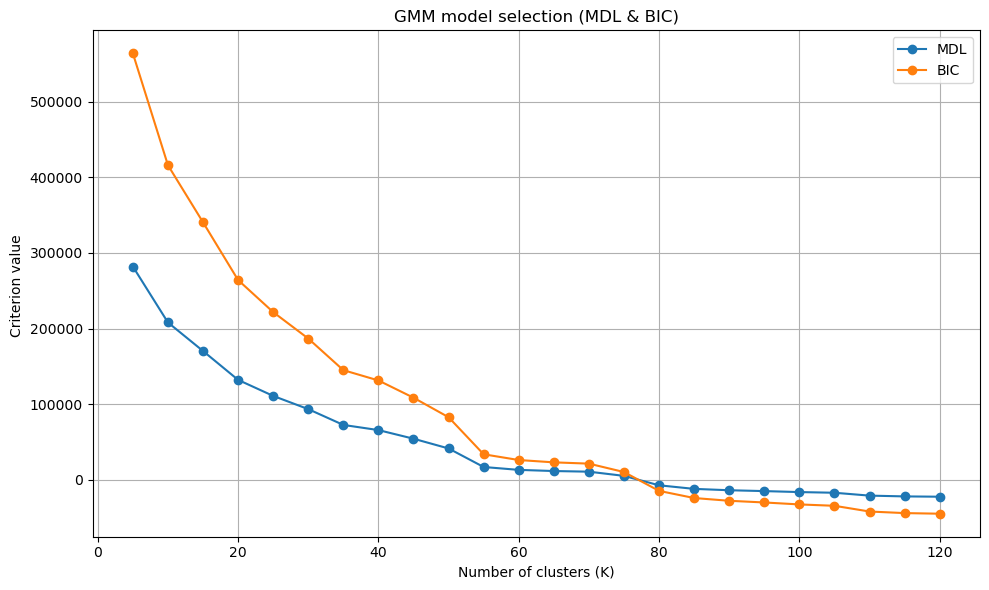

In [32]:

assert "splits_geohash" in globals(), "splits_geohash not found"

df_all = pd.concat(splits_geohash, ignore_index=True)

X = df_all[["LON", "LAT"]].to_numpy()   
N, D = X.shape

print(f"Data points: {N:,}, dimensions: {D}")


MAX_POINTS = 120_000
if N > MAX_POINTS:
    idx = np.random.RandomState(42).choice(N, MAX_POINTS, replace=False)
    X_fit = X[idx]
    print(f"Using subsample of {len(X_fit):,} points for model selection")
else:
    X_fit = X


def num_gmm_params(K, D):
    return (K - 1) + K * D + K * (D * (D + 1) / 2)

def mdl_score(gmm, X):
    N = X.shape[0]
    K = gmm.n_components
    D = X.shape[1]

    NM = num_gmm_params(K, D)
    logL = gmm.score(X) * N
    mdl = 0.5 * NM * np.log(N) - logL
    return mdl


K_VALUES = range(5, 125, 5)

MDL, BIC = [], []

for K in tqdm(K_VALUES, desc="Fitting GMMs"):
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="full",
        n_init=1,
        max_iter=150,
        tol=1e-4,
        reg_covar=1e-6,
        random_state=42
    )
    gmm.fit(X_fit)

    MDL.append(mdl_score(gmm, X_fit))
    BIC.append(gmm.bic(X_fit))


plt.figure(figsize=(10, 6))
plt.plot(K_VALUES, MDL, marker="o", label="MDL")
plt.plot(K_VALUES, BIC, marker="o", label="BIC")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Criterion value ")
plt.title("GMM model selection (MDL & BIC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


From the above plot it is evident that both BIC and MDL reach a minimum value before they stabilize at K=80-85, indicating that a GMM with 80-85 components provides the best balance between model fit and complexity for this dataset. Therefore, we select K=80 as the optimal number of mixture components for our GMM.

Following the model selection, we train a GMM with the chosen number of components (K=80) on the entire dataset to capture the underlying distribution of AIS points. The trained GMM is then visualized on a satellite map, with ellipses representing the Gaussian components. 

In [33]:
OUT_HTML = "gmm_whole_dataset_map.html"
POINTS_TOTAL = 30000      
ELLIPSE_PTS = 80
N_STD = 2.0
ELLIPSE_COLOR = "yellow"

N_COMPONENTS = 80  

assert "splits_geohash" in globals(), "splits_geohash not found"
df_all = pd.concat(splits_geohash, ignore_index=True)

required = ["LON", "LAT", "LON_original", "LAT_original"]
missing = [c for c in required if c not in df_all.columns]
if missing:
    raise RuntimeError(f"Missing columns in merged dataset: {missing}")


Xz = df_all[["LON", "LAT"]].to_numpy() 
gmm_all = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type="full",
    n_init=5,
    tol=1e-5,
    max_iter=200,
    reg_covar=1e-6,
    random_state=42
)
gmm_all.fit(Xz)
print(f" Trained GMM on full dataset: K={N_COMPONENTS}, converged={gmm_all.converged_}")


def fit_affine(z, x):
    z = np.asarray(z, dtype=float)
    x = np.asarray(x, dtype=float)
    m = np.isfinite(z) & np.isfinite(x)
    z = z[m]; x = x[m]
    if len(z) < 10:
        raise RuntimeError("Not enough points to fit inverse transform.")
    z_mean = z.mean()
    x_mean = x.mean()
    var_z = np.var(z)
    if var_z < 1e-12:
        raise RuntimeError("Standardized column variance ~0; cannot fit transform.")
    cov_zx = np.mean((z - z_mean) * (x - x_mean))
    a = cov_zx / var_z
    b = x_mean - a * z_mean
    return float(a), float(b)

a_lon, b_lon = fit_affine(df_all["LON"].values, df_all["LON_original"].values)
a_lat, b_lat = fit_affine(df_all["LAT"].values, df_all["LAT_original"].values)
D = np.diag([a_lon, a_lat])  

print("Estimated inverse transform:")
print(f"  LON_original ≈ {a_lon:.6f} * LON + {b_lon:.6f}")
print(f"  LAT_original ≈ {a_lat:.6f} * LAT + {b_lat:.6f}")

def z_to_lonlat_params(mean_z, cov_z):
    mean_x = np.array([a_lon * mean_z[0] + b_lon, a_lat * mean_z[1] + b_lat], dtype=float)
    cov_x = D @ cov_z @ D
    return mean_x, cov_x


def gaussian_ellipse_points(mean_lonlat, cov_lonlat, n_std=2.0, n=70):
    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    eigvals, eigvecs = np.linalg.eigh(cov_lonlat)
    eigvals = np.maximum(eigvals, 1e-14)
    A = eigvecs @ np.diag(np.sqrt(eigvals))

    pts = mean_lonlat.reshape(2, 1) + n_std * (A @ circle)
    return pts.T 


center_lat = float(df_all["LAT_original"].mean())
center_lon = float(df_all["LON_original"].mean())

m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles=None)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri — Source: Esri, Maxar, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles="CartoDB positron",
    name="Light (CartoDB)",
    overlay=False,
    control=True
).add_to(m)


fg_points = FeatureGroup(name="AIS points (sampled)", show=True)

if len(df_all) > POINTS_TOTAL:
    df_plot = df_all.sample(n=POINTS_TOTAL, random_state=42)
else:
    df_plot = df_all

for lat, lon in zip(df_plot["LAT_original"].values, df_plot["LON_original"].values):
    folium.CircleMarker(
        location=[float(lat), float(lon)],
        radius=1.4,
        color="white",
        fill=True,
        fill_opacity=0.35,
        weight=0
    ).add_to(fg_points)

fg_points.add_to(m)

fg_gmm = FeatureGroup(name=f"GMM ellipses (K={N_COMPONENTS}, {N_STD}σ)", show=True)

for k in range(gmm_all.n_components):
    mean_z = gmm_all.means_[k]        
    cov_z  = gmm_all.covariances_[k]  

    mean_x, cov_x = z_to_lonlat_params(mean_z, cov_z)  
    ellipse_lonlat = gaussian_ellipse_points(mean_x, cov_x, n_std=N_STD, n=ELLIPSE_PTS)

    # folium wants (lat, lon)
    ellipse_latlon = [(float(p[1]), float(p[0])) for p in ellipse_lonlat]

    folium.Polygon(
        locations=ellipse_latlon,
        color=ELLIPSE_COLOR,
        weight=2,
        fill=False,
        opacity=0.9
    ).add_to(fg_gmm)

fg_gmm.add_to(m)

LayerControl(collapsed=False).add_to(m)


m.save(OUT_HTML)



 Trained GMM on full dataset: K=80, converged=True
Estimated inverse transform:
  LON_original ≈ 0.031476 * LON + -118.228041
  LAT_original ≈ 0.016767 * LAT + 33.745099


In the following cell, in the trained GMMs are bounded by polygons to approximate berthing and anchoring areas. 

In [34]:
proj_wgs84 = CRS("EPSG:4326")
proj_merc = CRS("EPSG:3857")
to_meters = Transformer.from_crs(proj_wgs84, proj_merc, always_xy=True).transform
to_degrees = Transformer.from_crs(proj_merc, proj_wgs84, always_xy=True).transform


def gaussian_ellipse_points(mean_lonlat, cov_lonlat, n_std=2.0, n=70):
    theta = np.linspace(0, 2*np.pi, n)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    eigvals, eigvecs = np.linalg.eigh(cov_lonlat)
    eigvals = np.maximum(eigvals, 1e-14)
    A = eigvecs @ np.diag(np.sqrt(eigvals))
    pts = mean_lonlat.reshape(2, 1) + n_std * (A @ circle)
    return pts.T


center_lat = float(df_all["LAT_original"].mean())
center_lon = float(df_all["LON_original"].mean())

m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles=None)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri — Source: Esri, Maxar, Earthstar Geographics",
    name="Esri Satellite",
    overlay=False,
    control=True
).add_to(m)


folium.TileLayer("CartoDB positron", name="Light").add_to(m)


fg_points = folium.FeatureGroup(name="AIS Points", show=True)
fg_ellipses = folium.FeatureGroup(name="GMM Ellipses", show=True)
fg_boxes = folium.FeatureGroup(name="Bounding Boxes", show=True)


for lat, lon in zip(df_all["LAT_original"], df_all["LON_original"]):
    folium.CircleMarker(
        location=[lat, lon],
        radius=1,
        color="white",
        fill=True,
        fill_opacity=0.3,
        weight=0
    ).add_to(fg_points)


for k in range(gmm_all.n_components):
    mean_z = gmm_all.means_[k]
    cov_z = gmm_all.covariances_[k]
    
    mean_x, cov_x = z_to_lonlat_params(mean_z, cov_z)

    ellipse_pts = gaussian_ellipse_points(mean_x, cov_x, n_std=2.0, n=80)
    ellipse_poly = Polygon([(float(p[0]), float(p[1])) for p in ellipse_pts])
    poly_m = transform(to_meters, ellipse_poly)
    box_m = poly_m.minimum_rotated_rectangle
    box_deg = transform(to_degrees, box_m)
    coords = [(lat, lon) for lon, lat in box_deg.exterior.coords]

   
    folium.Polygon(
        locations=[(float(p[1]), float(p[0])) for p in ellipse_pts],
        color="yellow",
        weight=2,
        fill=False
    ).add_to(fg_ellipses)

    
    folium.Polygon(
        locations=coords,
        color="orange",
        weight=2,
        fill=True,
        fill_opacity=0.2
    ).add_to(fg_boxes)


fg_points.add_to(m)
fg_ellipses.add_to(m)
fg_boxes.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)


m.save("gmm_satellite_map.html")



The polygons from the GMM ellipses and bounding boxes are visualized in the above created html. It is observed that the polygons can be split further into smaller sections to better fit the actual vessel shapes. This indicates that while the GMM provides a good overall approximation of vessel distributions, further refinement is needed to accurately capture the complex geometries of individual vessels. The last step will refine the polygons by splitting them into smaller ones that take into account the discontinuities in GMM ellipses that merge 2 or more vessels into one polygon. Those will be split further. 

In [ ]:
MAX_POINTS_TO_PLOT = 2500     
EPS_METERS = 40              
MIN_SAMPLES = 15             
ELLIPSE_STD = 2.0            
RANDOM_STATE = 42


m_poly = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles=None
)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri",
    name="Satellite",
    overlay=False,
    control=True
).add_to(m_poly)


if len(df_all) > MAX_POINTS_TO_PLOT:
    df_plot = df_all.sample(n=MAX_POINTS_TO_PLOT, random_state=RANDOM_STATE)
else:
    df_plot = df_all

fg_points = folium.FeatureGroup(
    name=f"AIS Points (sample {len(df_plot)})",
    show=True
)

for lat, lon in zip(df_plot["LAT_original"], df_plot["LON_original"]):
    folium.CircleMarker(
        location=[float(lat), float(lon)],
        radius=1,
        color="white",
        fill=True,
        fill_opacity=0.3,
        weight=0
    ).add_to(fg_points)

fg_points.add_to(m_poly)

fg_polygons = folium.FeatureGroup(name="Polygons", show=True)

for k in range(gmm_all.n_components):

    mean_z = gmm_all.means_[k]
    cov_z  = gmm_all.covariances_[k]

    
    mean_ll, cov_ll = z_to_lonlat_params(mean_z, cov_z)

    
    ellipse_pts = gaussian_ellipse_points(
        mean_ll, cov_ll,
        n_std=ELLIPSE_STD,
        n=80
    )

    ellipse_poly = Polygon([(float(x), float(y)) for x, y in ellipse_pts])

    
    ellipse_proj = transform(to_meters, ellipse_poly)
    box_proj = ellipse_proj.minimum_rotated_rectangle
    box_deg = transform(to_degrees, box_proj)

    box = Polygon([(x, y) for x, y in box_deg.exterior.coords])

   
    ais_inside = df_all[
        df_all.apply(
            lambda r: box.contains(Point(float(r["LON_original"]), float(r["LAT_original"]))),
            axis=1
        )
    ].copy()

    if len(ais_inside) < MIN_SAMPLES:
        continue

    coords_m = np.array([
        transform(to_meters, Point(float(lon), float(lat))).coords[0]
        for lon, lat in zip(
            ais_inside["LON_original"],
            ais_inside["LAT_original"]
        )
    ])

    db = DBSCAN(
        eps=EPS_METERS,
        min_samples=MIN_SAMPLES
    ).fit(coords_m)

    labels = db.labels_
    ais_inside["subcluster"] = labels

   
    for sub in np.unique(labels):

        if sub == -1:
            continue

        sub_coords = coords_m[labels == sub]
        if len(sub_coords) < 3:
            continue

        mp = MultiPoint([Point(x, y) for x, y in sub_coords])
        rect_proj = mp.convex_hull.minimum_rotated_rectangle
        rect_deg = transform(to_degrees, rect_proj)

        coords = [
            (float(lat), float(lon))
            for lon, lat in rect_deg.exterior.coords
        ]

        folium.Polygon(
            locations=coords,
            color="cyan",
            weight=2,
            fill=True,
            fill_opacity=0.4,
            popup=f"GMM {k} – sub {sub}"
        ).add_to(fg_polygons)

fg_polygons.add_to(m_poly)


folium.LayerControl(collapsed=False).add_to(m_poly)
m_poly.save("polygons_dbscan.html")




--------------------------END------------------------------------------